In [1]:
from scipy.stats import qmc
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.gaussian_process.kernels import Matern

In [2]:
#Function 3
#Extracting updated data and turning it into a pandas dataframe
data = pd.read_csv('Data/Week 6 - Function 3.csv') 
columns = ['Input 1', 'Input 2','Input 3', 'Outputs']
#Remove columns with NaN values
data = data.dropna(axis = 1)
data.columns = columns
#Add Week 7's data to our pandas dataframe
new_data7 = np.array([0.583115, 0.709624, 0.569389,-0.04490503647909851])
data.loc[len(data)] = new_data7
#Add Week 8's data to our pandas dataframe
new_data8 = np.array([0.591817, 0.469104, 0.425630,-0.014179000315548545])
data.loc[len(data)] = new_data8
#Add Week 9's data to our pandas dataframe
new_data9 = np.array([0.435075, 0.400070, 0.435027,-0.017917485041419805])
data.loc[len(data)] = new_data9
#Add Week 10's data to our pandas dataframe
new_data10 = np.array([0.844429, 0.529216, 0.424188,-0.002260605321424087])
data.loc[len(data)] = new_data10
#Add Week 11's data to our pandas dataframe
new_data11 = np.array([0.647802, 0.594053, 0.428390,-0.008499145058900318])
data.loc[len(data)] = new_data11
data

,Input 1,Input 2,Input 3,Outputs
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


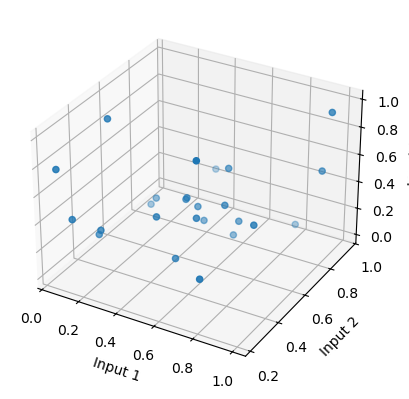

In [3]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2', 'Input 3']])
Y = np.array(data[['Outputs']])
#Visualise already explored points
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:,0], X[:,1], X[:,2])

ax.set_xlabel("Input 1")
ax.set_ylabel("Input 2")
ax.set_zlabel("Input 3")

plt.show()

In [5]:
#Using latin hypercube sampling to initialise a set of candidate points in a trust region
#Initialise points in the unit hypercube
d = 3
n = 20000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n) 

#Scale points generated in the unit hypercube to be inside trust region
#Trust hypercube of radius delta centered at best point with from observed data is 
#[x_best-delta, x_best_plus]
x_best = X[np.argmax(Y)]
#Set radius of hypercube
delta = 0.2
#lower and upper bounds of hypercube
lb = x_best-delta 
ub = x_best+delta

#scale points from unit hypercube to be inside trust region
scaled_grid = lb + grid * (ub-lb) 


In [6]:
#We now set the Kernel to be the Matern Kernel
nu = 2.5
kernel = Matern(
    length_scale_bounds=(1e-2, 2),
    nu= nu
)
print("Kernel:", kernel)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)
print(gp)
gp.fit(X,Y)

mu, std = gp.predict(scaled_grid, return_std = True)

Kernel: Matern(length_scale=1, nu=2.5)
GaussianProcessRegressor(kernel=Matern(length_scale=1, nu=2.5),
                         normalize_y=True)


In [7]:
#Calculate UCB
beta = 0.2 #set exploration parameter
UCB = mu + beta*std 
#Find point that maximises UCB acquisition function
x_next = scaled_grid[np.argmax(UCB)]
print("Next suggested point:", np.round(x_next,6))


Next suggested point: [0.645444 0.532377 0.513583]


In [3]:
#Week 12
#Add new data
new_data = np.array([0.645444, 0.532377, 0.513583, -0.01341414044748011])
data.loc[len(data)] = new_data
data

,Input 1,Input 2,Input 3,Outputs
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


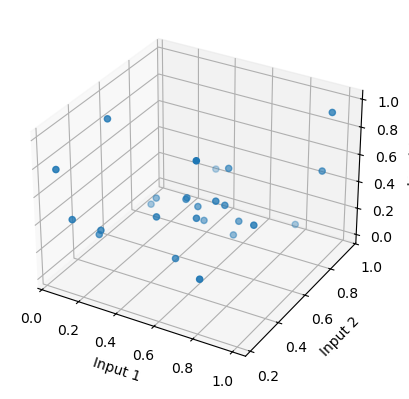

In [4]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2', 'Input 3']])
Y = np.array(data[['Outputs']])
#Visualise already explored points
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:,0], X[:,1], X[:,2])

ax.set_xlabel("Input 1")
ax.set_ylabel("Input 2")
ax.set_zlabel("Input 3")

plt.show()

In [6]:
#Using latin hypercube sampling to initialise a set of candidate points in a trust region
#Initialise points in the unit hypercube
d = 3
n = 20000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n) 

#Scale points generated in the unit hypercube to be inside trust region
#Trust hypercube of radius delta centered at best point with from observed data is 
#[x_best-delta, x_best_plus]
x_best = X[np.argmax(Y)]
#Set radius of hypercube to 90% of previous iteration since there was no improvement
delta = 0.2*0.9
#lower and upper bounds of hypercube
lb = x_best-delta 
ub = x_best+delta

#scale points from unit hypercube to be inside trust region
scaled_grid = lb + grid * (ub-lb) 
print("Center of hypercube, upper bound, lower bound:", x_best, ub, lb)

Center of hypercube, upper bound, lower bound: [0.844429 0.529216 0.424188] [1.024429 0.709216 0.604188] [0.664429 0.349216 0.244188]


In [7]:
#We now set the Kernel to be the Matern Kernel
nu = 2.5
kernel = Matern(
    length_scale_bounds=(1e-2, 2),
    nu= nu
)
print("Kernel:", kernel)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)
print(gp)
gp.fit(X,Y)

mu, std = gp.predict(scaled_grid, return_std = True)

Kernel: Matern(length_scale=1, nu=2.5)
GaussianProcessRegressor(kernel=Matern(length_scale=1, nu=2.5),
                         normalize_y=True)


In [8]:
#Calculate UCB
beta = 0.2 #set exploration parameter
UCB = mu + beta*std 
#Find point that maximises UCB acquisition function
x_next = scaled_grid[np.argmax(UCB)]
print("Next suggested point:", np.round(x_next,6))

Next suggested point: [0.895633 0.561001 0.467152]


In [5]:
#Week 12
#Add new data
new_data = np.array([0.895633, 0.561001, 0.467152, -0.0010686760066704168])
data.loc[len(data)] = new_data
data

,Input 1,Input 2,Input 3,Outputs
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


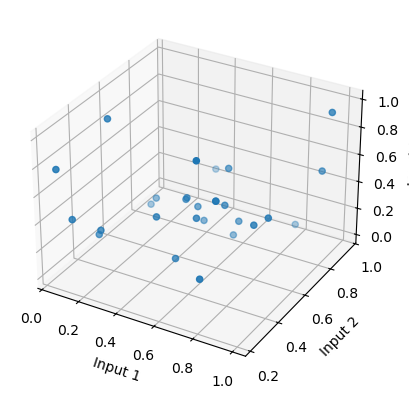

In [6]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2', 'Input 3']])
Y = np.array(data[['Outputs']])
#Visualise already explored points
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:,0], X[:,1], X[:,2])

ax.set_xlabel("Input 1")
ax.set_ylabel("Input 2")
ax.set_zlabel("Input 3")

plt.show()

In [9]:
#Using latin hypercube sampling to initialise a set of candidate points in a trust region
#Initialise points in the unit hypercube
d = 3
n = 20000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n) 

#Scale points generated in the unit hypercube to be inside trust region
#Trust hypercube of radius delta centered at best point with from observed data is 
#[x_best-delta, x_best_plus]
x_best = X[np.argmax(Y)]
#Increase radius of hypercube by 90% of previous iteration since there was an improvement
delta = 0.2*0.9*1.1
#lower and upper bounds of hypercube
lb = x_best-delta 
ub = x_best+delta

#scale points from unit hypercube to be inside trust region
scaled_grid = np.clip(lb + grid * (ub-lb), 0,1) 
print("Center of hypercube, upper bound, lower bound:", x_best)
print("Upper bound:", ub)
print("Lower bound:", lb)

Center of hypercube, upper bound, lower bound: [0.895633 0.561001 0.467152]
Upper bound: [1.093633 0.759001 0.665152]
Lower bound: [0.697633 0.363001 0.269152]


In [16]:
#We now set the Kernel to be the Matern Kernel
nu = 3
kernel = Matern(
    length_scale_bounds=(1e-2, 2),
    nu= nu
)
print("Kernel:", kernel)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)
print(gp)
gp.fit(X,Y)

mu, std = gp.predict(scaled_grid, return_std = True)

Kernel: Matern(length_scale=1, nu=3)
GaussianProcessRegressor(kernel=Matern(length_scale=1, nu=3), normalize_y=True)


In [17]:
#Calculate UCB
beta = 0.2 #set exploration parameter
UCB = mu + beta*std 
#Find point that maximises UCB acquisition function
x_next = scaled_grid[np.argmax(UCB)]
print("Next suggested point:", np.round(x_next,6))

Next suggested point: [0.888162 0.515404 0.445466]
